New K-means algorithm, the other one became too convoluted, needed proper commenting with the new format. Old file still exists so I have access to loss function algorithm


In [178]:
# Step 1: Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import pairwise_distances
import csv
import pandas as pd
from collections import Counter
from sklearn.metrics import normalized_mutual_info_score
from sklearn.cluster import MiniBatchKMeans

In [179]:
# Step 2: Load my data
def labelmaker(events, e_density, noise, filename = None, folder = None): 
    '''creates labels based on my naming convention for different files, keeps it consistent and easy'''
    if folder: 
        folder = folder + '/'

    if filename: 
        datafile = str(filename) 
    else: 
        datafile = str(events) + 'ev_n' + str(noise) + '_es' + str(int(e_density*100))    

    labelfile = 'labels_' + datafile + '.csv'
    sourcefile = 'sources_' + datafile + '.csv'
    ai_labelfile = datafile + '_AIlabels' + '.csv'
    centroidfile = datafile + '_centroids' + '.csv'
    datafile = datafile + '.csv'

    if folder: 
        datafile = folder + datafile 
        centroidfile = folder + centroidfile 
        ai_labelfile = folder + ai_labelfile 
        labelfile = folder + labelfile 
        sourcefile = folder + sourcefile 

    
    return datafile, labelfile, sourcefile, ai_labelfile, centroidfile


def pull(datafile, labelfile, sourcefile): 
    columns = ['x [px]', 'y [px]', 't [s]', 't_relToExtTrigger [s]']
    
    dataread = pd.read_csv(datafile) 
    all_data = np.array(dataread[columns])
    data = all_data[:,:3]
    
    labelread = pd.read_csv(labelfile)
    labels = np.array(labelread['labels'])
    
    sourceread = pd.read_csv(sourcefile) 
    all_sources = np.array(sourceread[columns])
    sources = all_sources[:,:3]

    return data, labels, sources

In [225]:
datafile, labelfile, sourcefile, ai_labelfile, centroidfile = labelmaker(1000, 1, 0, filename = '10000ev_mixed_n0', folder = 'big_datasets/formatted_for_empir')
data, labels, sources = pull(datafile, labelfile, sourcefile)
print(datafile)

big_datasets/formatted_for_empir/10000ev_mixed_n0.csv


In [213]:
# Step 3: Insert Loss Function for Optional Use 

def breaks(array): 
    '''This function takes an array, goes through it item by item, and returns the list of indices where the value changes'''
    value = array[0] 
    indices = []
    for index, ele in enumerate(array): 
        if ele != value:
            indices.append(index)
            value = array[index]
    indices.append(len(array))

    return indices

def sizes(indices): 
    '''This function takes a list of indices and calculates the number of items belonging to each value by taking the difference between 
    subsequent indices'''
    gaps = []
    prev=0
    for i in range(len(indices)):
        gaps.append(indices[i]-prev)
        prev = indices[i]

    return gaps

def modded_mode(array): 
    '''This function will return event labels, its a modification on a normal mode function where the label has to appear at least 33% of the time to be a label in that chunk.'''
    n = len(array)
    if n == 0: 
        return []
    
    threshold = n/3 
    counts = Counter(array)

    result = [key for key, count in counts.items() if count >= threshold]
    return result 

def clustering_loss(true_labels, ai_labels):
    # labels are already sorted by true labels predictions 

    # getting break indices and cluster sizes 
    break_indices = breaks(true_labels)
    gaps = sizes(break_indices)
    n_events = len(gaps)

    # initialize variables 
    counter = Counter()
    fractions_misIDs = []
    total_splits, ev_per_split = 0,0 
    total_splits = 0 
    total_misIDs = 0 


    # process each chunk that's separated by truth gaps 
    for start, end, gap in zip([0] + break_indices[:-1], break_indices, gaps):
        chunk = ai_labels[start:end]
        chunk_modes = modded_mode(chunk)

        # update counter
        counter.update(chunk_modes)
    
        e_in_split = len(chunk_modes) # number of ai events found in the chunk
        if e_in_split > 1: 
            total_splits += 1
            ev_per_split += e_in_split # if there is more than one, increase splits and events in split 
        
        misIDs = sum(1 for item in chunk if item not in chunk_modes)
        total_misIDs += misIDs
        fractions_misIDs.append(misIDs/gap)
    
    # Combination Statistics 
    repeat_labels = {k: v for k, v in counter.items() if v>1}
    total_combos = len(repeat_labels) # the amount of combinations is the same as the amount of labels that get repeated through the set 
    ev_per_combo = sum(repeat_labels.values())/total_combos if total_combos else 0 # sum all repeats together and average over number of combinations 
    frac_combos = total_combos / n_events # fraction of events experiencing combination
    
    # other stats 
    ev_per_split = ev_per_split/total_splits if total_splits else 0
    frac_splits = total_splits/n_events
    avg_misIDs = np.mean(fractions_misIDs)

    # output da resultssss
    # print(f"The fraction of splits over all events is {frac_splits}")
    # print(f"The average number of events involved in a single split is {ev_per_split}")
    # print(f"The fraction of combinations over all events is {frac_combos}")
    # print(f"The average number of events involved in a single combo is {ev_per_combo}")
    # print(f"The average fraction of photons misidentified in each event is {avg_misIDs}")

    return frac_splits, ev_per_split, frac_combos, ev_per_combo, avg_misIDs

def sourcing_loss(real_sources, ai_centroids, epsilon = 1e-10):
    '''does not allow for repeats'''
    errors = []
    used_indices = set()
    for coord in real_sources:
        # Compute distances to all points in list_b
        distances = np.linalg.norm(ai_centroids - real_sources, axis=1)

        # Find index of nearest unused point
        for idx in np.argsort(distances):
            if idx not in used_indices:
                nearest = ai_centroids[idx]
                used_indices.add(idx)
                break

        # Calculate percentage error
        
        error = np.linalg.norm(coord - nearest) 
        errors.append(error)

    return np.mean(errors)

# def sourcing_loss(real_sources, ai_centroids, epsilon=1e-10):
#     errors = []
#     for coord in real_sources:
#         # Compute distances to all centroids
#         distances = np.linalg.norm(ai_centroids - coord, axis=1)

#         # Find the nearest centroid (allowing repeats)
#         nearest = ai_centroids[np.argmin(distances)]

#         # Calculate error (distance)
#         error = np.linalg.norm(coord - nearest)
#         errors.append(error)

#     return np.mean(errors)

In [214]:
# # time based calculation
# maxtime = np.max(data[:,2])
# ev_per_sec = 487
# events = int(ev_per_sec*maxtime)

# photon based calculation 
photons = len(data)
avg_photons_per_event = 44.45
events = photons/avg_photons_per_event
print(events)

best_k = 100 

# kvals = np.linspace(events-5, events+5, 11)

# sse = []
# for k in kvals: 
#     kmeans = KMeans(n_clusters=int(k), random_state=42, tol = 0.00001, max_iter=500, n_init=5)
#     kmeans.fit(data)
#     sse.append(kmeans.inertia_)

# # plt.figure(figsize=(12,5))
# # plt.subplot(1, 2, 1)
# # plt.plot(kvals, sse, marker='o')
# # plt.title('Elbow Method')
# # plt.xlabel('Number of Clusters (k)')
# # plt.ylabel('SSE (Inertia)')

# # --- SILHOUETTE ANALYSIS ---
# silhouette_scores = []

# for k in kvals:
#     kmeans = KMeans(n_clusters=int(k), random_state=42)
#     cluster_labels = kmeans.fit_predict(data)
#     silhouette_avg = silhouette_score(data, cluster_labels)
#     silhouette_scores.append(silhouette_avg)

# # plt.subplot(1, 2, 2)
# # plt.plot(kvals, silhouette_scores, marker='o', color='orange')
# # plt.title('Silhouette Analysis')
# # plt.xlabel('Number of Clusters (k)')
# # plt.ylabel('Silhouette Score')

# # plt.tight_layout()
# # plt.show()

# best_k = kvals[np.argmax(silhouette_scores)]
# print(f"Best k according to Silhouette Score: {best_k}")



109.87626546681665


In [202]:
# Step 4: Run K-Means 

kmeans = KMeans(n_clusters = int(best_k), random_state=42, tol=0.001, max_iter=500, n_init=5)
kmeans.fit(data)
ai_labels = kmeans.labels_
ai_centroids = kmeans.cluster_centers_
nmi = normalized_mutual_info_score(labels, ai_labels)

Text(33.097222222222214, 0.5, 'Y Pixels')

<Figure size 640x480 with 0 Axes>

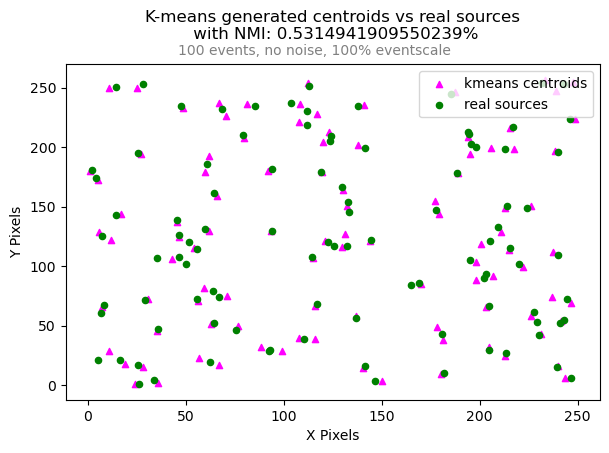

In [192]:
# Step 5: Plot results 

plt.figure()
plt.figure(figsize=(6, 5))
plt.scatter(ai_centroids[:,0], ai_centroids[:,1], c = 'magenta',s = 20, label = 'kmeans centroids', marker = '^')
plt.scatter(sources[:,0], sources[:,1], c = 'green', s = 20, label = 'real sources')
plt.title(f"K-means generated centroids vs real sources\n with NMI: {nmi}%", y = 1.05)
plt.suptitle("100 events, no noise, 100% eventscale", y=0.79, fontsize = 10, color = 'gray')
plt.legend()
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.xlabel('X Pixels')
plt.ylabel('Y Pixels')

In [226]:
### BATCHING K MEANS TO SAVE TIME 

mbk = MiniBatchKMeans(
    n_clusters=10000,
    batch_size=15,  # process 1024 samples at a time
    random_state=42, 
    tol = 0.00001, 
    max_iter=500
)
mbk.fit(data)
batched_ai_labels = mbk.labels_
batched_ai_clusters = mbk.cluster_centers_

batched_nmi = normalized_mutual_info_score(labels, batched_ai_labels)
batched_nmi

0.5846244769425001